<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 3: Aprendizaje supervisado o no supervisado

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*


**Objetivo**: Caracterizar los puntos de muestreo en base a la abundancia y las características de los ejemplares colectados para responder las demandas de la municipalidad.

1. **Caracterizar** los **puntos de muestreo** considerando los ejemplares pescados. Se debe considerar la variabilidad temporal.

2. **Agrupar** los puntos de muestreo mediante técnicas de análisis no supervisado.

3. **Describir** la variabilidad temporal.

4. **Redactar una recomendación** para el gobierno local que tenga por objetivo la subsistencia del recurso pesquero a lo largo del tiempo.

In [1]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

from scipy import stats

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

## 1. Carga del dataset original

In [2]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [3]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [4]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


## Limpieza del dataframe

La limpieza se orienta a obtener un dataframe limpio y preprocesado para la posterior implementacion del algoritmo de clustering.

Los criterios tomados en la misma son distintos a los usados en lo trabajos anteriores, en especial aquellos relativos a las columnas. Estos se irán describiendo y justificando debidamente durante la limpieza.

In [5]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


In [6]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


Debido al alto porcentaje de entradas nulas, se descartan las columnas `ancho_caparazon`, `largo_quela` y `ancho_quela`, pues no permiten sacar conclusiones sobre la muestra.


In [7]:
df_raw.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela'], inplace=True)

Se define la función de extracción del número de trampas, contenido en la columna `tipo`. Esto permite aprovechar la disponibilidad de esta información numérica posteriormente.

In [8]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

In [9]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos de cálculos de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos de cálculos de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


In [10]:
# Definicion de la prioridad cronologica de las campañas
orden_campanas = {
    'ene_96': 1,
    'abril_96': 2,
    'jul_96': 3,
    'oct_96': 4,
    'jul_97': 5,
    'oct_97': 6,
    'oct_98': 7
}

# Se convierte a categorica y se ordena por fecha
df_raw['fecha'] = pd.Categorical(df_raw['fecha'], categories=orden_campanas, ordered=True)

# Se ordena con 'key' y se reinicia el índice
#df_raw = df_raw.sort_values(by='fecha', key=lambda x: x.map(orden_campanas)).reset_index(drop=True)

El porcentaje de nulos del dataframe de trabajo actualmente es el siguiente:

In [11]:
print("="*50)
print("Resumen de limpieza inicial - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen de limpieza inicial - Estado actual del df

Filas: 9,105 | Columnas: 16

observaciones       98.58
parasito            97.25
cirripedio          86.23
huevos              62.47
longitud            12.73
latitud             12.73
num_trampas          2.64
profundidad          1.50
localizacion         1.21
estado_caparazon     0.02
dtype: float64


Debido al alto porcentaje de valores faltantes y su poca relevancia para nuestro estudio, se descartan las columnas `cirripedio`, `parasito` y `observaciones`.

In [12]:
# Copia posterior a la limpieza inicial
df_clean = df_raw.copy()

In [13]:
# eliminar las columnas en caso de que esten en el dataframe
if 'cirripedio' in df_clean.columns:
  df_clean.drop(columns=['cirripedio'], inplace=True)
if 'parasito' in df_clean.columns:
  df_clean.drop(columns=['parasito'], inplace=True)
if 'observaciones' in df_clean.columns:
  df_clean.drop(columns=['observaciones'], inplace=True)

A continuación se realiza la corrección de los valores de la columna huevos de la misma manera que se hizo en trabajos anteriores.

In [14]:
# Correccion huevos
# Descarte de huevos = po
df_clean = df_clean[df_clean['huevos'] != 'po']

# Diccionario de correcciones:
correccion_huevos = {
    # Corrección de texto
    'conojos': '3',
    '7 en 1': '1'
}

# Aplicar el reemplazo
df_clean['huevos'] = df_clean['huevos'].replace(correccion_huevos)
df_clean['huevos'] = df_clean['huevos'].apply(lambda x: float(x))

Como se mencionó en el trabajo práctico 2, focalizamos nuestro estudio únicamente en los centollones.

Se filtra el dataframe y se elimina la columna, pues ahora tiene un valor único que no aporta varianza al conjunto.

In [15]:
# Descarte de registros de centollas
df_segmented = df_clean[df_clean['especie'] != 1].copy()

# Descarte de columna 'especie'
if 'especie' in df_segmented.columns:
  df_segmented.drop(columns=['especie'], inplace=True)

# Tamaño del dataframe segmentado
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 12


A continuación, se implementa un **Indicador de madurez sexual**

Habiendo segmentado los registros, se agrega una nueva columna booleana indicando si el centollón registrado es sexualmente maduro o no. Para ello, se utiliza el siguiente criterio a partir de información provista por nuestra mentora:

Si el largo del caparazón de un macho es al menos $50,2 mm$, este es sexualmente maduro. En el caso de las hembras, su largo debe ser al menos $60,6 mm$.

La codificación será entonces:

- 0 sexualmente inmaduro,
- 1 sexualmente maduro

In [16]:
# Condiciones de madurez según sexo y talla (mm)
macho_maduro = (df_segmented['sexo'] == 1) & (df_segmented['largo_caparazon'] >= 50.2)
hembra_madura = (df_segmented['sexo'] == 2) & (df_segmented['largo_caparazon'] >= 60.6)

# Nueva columna con codificación 1 (Maduro) y 0 (Inmaduro)
df_segmented['madurez_sexual'] = np.where(macho_maduro | hembra_madura, 1, 0)

# Tamaño del dataframe
print("="*50)
print("Resumen - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_segmented.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen - Estado actual del df

Filas: 8,860 | Columnas: 13

huevos          62.19
longitud        11.94
latitud         11.94
num_trampas      1.86
localizacion     1.24
profundidad      1.08
dtype: float64


In [17]:
df_segmented.columns

Index(['fecha', 'rk', 'tipo', 'localizacion', 'latitud', 'longitud',
       'profundidad', 'sexo', 'estado_caparazon', 'largo_caparazon', 'huevos',
       'num_trampas', 'madurez_sexual'],
      dtype='object')

## Tabla descriptiva de campañas

Se implementa una tabla que muestra algunos indicadores representativos de los datos agrupados por puntos de extracción. Para considerar la variación temporal, fue necesario validar si durante distintas campañas se pescó en un mismo punto. Habiendo verificado que esto no ocurría, se procedió a confeccionar la tabla antes descripta.


In [18]:
# Cuenta de fechas distintas por cada localizacion
fechas_por_loc = df_segmented.groupby('localizacion')['fecha'].nunique()

# Localizaciones con mas de 1 fecha
locs_multiples_fechas = fechas_por_loc[fechas_por_loc > 1]

print(
    f'Total de localizaciones con más de una fecha:'
    f' {len(locs_multiples_fechas)} de {len(fechas_por_loc)}'
)
print('\nDetalle de fechas por localización:')
print(locs_multiples_fechas)

Total de localizaciones con más de una fecha: 0 de 57

Detalle de fechas por localización:
Series([], Name: fecha, dtype: int64)


No hay puntos de pesca con más de una fecha asociada, volviendo la `localización` una variable de agrupación idónea. Veamos si hay valores nulos en la misma.

In [19]:
# Localizacion nula en df_segmented
df_segmented[df_segmented['localizacion'].isnull()]

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,sexo,estado_caparazon,largo_caparazon,huevos,num_trampas,madurez_sexual
11050,jul_97,1,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,3.0,90.1,NaN,NaN,1
11051,jul_97,2,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,3.0,87.2,NaN,NaN,1
11052,jul_97,3,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,4.0,63.5,1.0,NaN,1
11053,jul_97,4,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,88.0,NaN,NaN,1
11054,jul_97,5,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,85.7,NaN,NaN,1
11055,jul_97,6,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,88.7,NaN,NaN,1
11056,jul_97,7,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,92.5,NaN,NaN,1
11057,jul_97,8,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,92.3,NaN,NaN,1
11058,jul_97,9,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,3.0,92.0,NaN,NaN,1
11059,jul_97,10,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,1,4.0,83.1,NaN,NaN,1


Los valores nulos están todos asociados a la misma campaña y, afortunadamente, podemos inferir el nombre de la ubicación a partir del texto reportado en la columna `tipo`.

In [20]:
# Condición: 'tipo' coincide Y 'localizacion' es nula
condicion = (
    df_segmented['tipo'] == 'Captura total trampas wp 149'
) & df_segmented['localizacion'].isna()

# Imputar unicamente en las filas que cumplen la condicion
df_segmented.loc[condicion, 'localizacion'] = 'wp149'

Ahora que no hay localizaciones nulas, utilizamos la columna como identificador para crear el dataset de campañas.

Por otro lado, hay 6 campañas sin latitud ni longitud (el 12% del dataset antes mensionado), y 57 registradas. Este punto debe considerarse si se desea hacer un estudio minucioso y numérico de las ubicaciones de los puntos de pesca.

A continuación, se realiza la tabla descriptiva por campañas

La misma introduce los conceptos de hembras ovígeras y hembras vulnerables. En este contexto, se entiende por:

Hembras ovígeras: Aquellas cuyo estadío reportado en huevos indique presencia explícita de huevos (sin ojos, sin ojos con mancha blanca, con ejos), procesos de eclosionado, embriogénesis heterogénea o trazas.

Hembras vulnerables: Inluye los registros de la categoría anterior y estadíos post-ovígeros, ya que el caparazón de las hembras es blando y por ende es más susceptible de sufrir daños graves por manipulación y emergimiento.

In [21]:
# Dataframe de trabajo
df_preprocesado = df_segmented.copy()

# Banderas a nivel de registro individual (df_segmented)
df_preprocesado['es_macho'] = df_preprocesado['sexo'].isin([1, 'Macho', 'macho'])
df_preprocesado['es_hembra'] = df_preprocesado['sexo'].isin([2, 'Hembra', 'hembra'])

# Filtrar hembras con evaluación efectiva de huevos
df_preprocesado['tiene_registro_huevos'] = (
    df_preprocesado['es_hembra'] & df_preprocesado['huevos'].notna()
)

# Caracterizacion de hembras en vulnerable y ovigera
cod_vulnerables = [1, 2, 3, 30, 4, 40, 5, 6, 7]
cod_ovigeras = [1, 2, 3, 30, 4, 40, 6, 7]

df_preprocesado['es_vulnerable'] = df_preprocesado[
    'tiene_registro_huevos'
] & df_preprocesado['huevos'].isin(cod_vulnerables)
df_preprocesado['es_ovigera'] = df_preprocesado[
    'tiene_registro_huevos'
] & df_preprocesado['huevos'].isin(cod_ovigeras)

# Condición de Madurez Sexual
macho_maduro = df_preprocesado['es_macho'] & (
    df_preprocesado['largo_caparazon'] >= 50.2
)
hembra_madura = df_preprocesado['es_hembra'] & (
    df_preprocesado['largo_caparazon'] >= 60.6
)
df_preprocesado['maduro'] = np.where(macho_maduro | hembra_madura, 1, 0)

In [22]:
# Agrupación ÚNICA por LOCALIZACIÓN (Dataset de Campañas)

df_campanas = (
    df_preprocesado[df_preprocesado['num_trampas'] > 0]
    .groupby('localizacion', observed=False)
    .agg(
        fecha=('fecha', 'first'),
        tipo_pesca=('tipo', 'first'),
        n_trampas=('num_trampas', 'first'),
        n_total=('sexo', 'count'),
        n_machos=('es_macho', 'sum'),
        n_hembras_totales=('es_hembra', 'sum'),
        n_hembras_evaluadas=('tiene_registro_huevos', 'sum'),
        n_vulnerables=('es_vulnerable', 'sum'),
        n_ovigeras=('es_ovigera', 'sum'),
        n_maduros=('maduro', 'sum'),
    )
    .reset_index()
)


# Métricas e Indicadores a Nivel de Campaña

# Indicadores de Densidad (IAR de la campaña)
df_campanas['iar_total'] = df_campanas['n_total'] / df_campanas['n_trampas']
df_campanas['iar_macho'] = df_campanas['n_machos'] / df_campanas['n_trampas']
df_campanas['iar_hembra'] = (
    df_campanas['n_hembras_totales'] / df_campanas['n_trampas']
)

# Estructura Poblacional General
df_campanas['pct_hembras'] = np.where(
    df_campanas['n_total'] > 0,
    (df_campanas['n_hembras_totales'] / df_campanas['n_total']) * 100,
    0,
)

df_campanas['pct_maduros'] = np.where(
    df_campanas['n_total'] > 0,
    (df_campanas['n_maduros'] / df_campanas['n_total']) * 100,
    0,
)

# Métricas Reproductivas (NaN si n_hembras_evaluadas == 0)
df_campanas['pct_vulnerables'] = np.where(
    df_campanas['n_hembras_evaluadas'] > 0,
    (df_campanas['n_vulnerables'] / df_campanas['n_hembras_evaluadas']) * 100,
    np.nan,
)

df_campanas['carga_ovigera_pct'] = np.where(
    df_campanas['n_hembras_evaluadas'] > 0,
    (df_campanas['n_ovigeras'] / df_campanas['n_hembras_evaluadas']) * 100,
    np.nan,
)

In [23]:
# Estadio Dominante (Filtrando evaluadas previamente)

df_evaluadas = df_preprocesado[df_preprocesado['tiene_registro_huevos']]

estadios_loc = (
    df_evaluadas.groupby('localizacion', observed=False)['huevos']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    .reset_index(name='estadio_dominante')
)

df_campanas = df_campanas.merge(estadios_loc, on='localizacion', how='left')

mapa_estadios = {
    0: 'Anovígera / Sin actividad',
    1: 'Incubación temprana (Sin ojos)',
    2: 'Incubación intermedia (Mancha blanca)',
    3: 'Incubación avanzada (Con ojos)',
    30: 'Inicio Incubación avanzada',
    4: 'Eclosión activa',
    40: 'Inicio Eclosión',
    5: 'Post-eclosión / Muda reciente',
    6: 'Embriogénesis heterogénea',
    7: 'Trazas / Final de incubación',
}

df_campanas['estado_reproductivo_campana'] = (
    df_campanas['estadio_dominante'].map(mapa_estadios).fillna('Sin Registro')
)

columnas_numericas = [
    'iar_total',
    'iar_macho',
    'iar_hembra',
    'pct_hembras',
    'pct_maduros',
    'pct_vulnerables',
    'carga_ovigera_pct',
]

# Crear una vista redondeada a 3 decimales solo para inspección visual
df_vista = df_campanas.copy()
df_vista[columnas_numericas] = df_vista[columnas_numericas].round(3)

print("Muestra formateada a 3 decimales (Memoria intacta):")
df_vista.head()

Muestra formateada a 3 decimales (Memoria intacta):


,localizacion,fecha,tipo_pesca,n_trampas,n_total,n_machos,n_hembras_totales,n_hembras_evaluadas,n_vulnerables,n_ovigeras,n_maduros,iar_total,iar_macho,iar_hembra,pct_hembras,pct_maduros,pct_vulnerables,carga_ovigera_pct,estadio_dominante,estado_reproductivo_campana
0,frente bal. Ponsatti,ene_96,Captura total de 3 trampas,3.0,234,79,155,143,111,109,220,78.000,26.333,51.667,66.239,94.017,77.622,76.224,1.0,Incubación temprana (Sin ojos)
1,E I. Martillo,jul_96,Captura total de 1 trampa,1.0,539,448,91,88,26,26,508,539.000,448.000,91.000,16.883,94.249,29.545,29.545,0.0,Anovígera / Sin actividad
2,N Snipe al traves con la baliza p. de los indios,ene_96,Captura total de 4 trampas,4.0,191,45,146,136,130,97,191,47.750,11.250,36.500,76.440,100.000,95.588,71.324,1.0,Incubación temprana (Sin ojos)
3,S islote Belgrano/punta navarro,ene_96,Captura total de 2 trampas,2.0,121,28,93,91,86,78,120,60.500,14.000,46.500,76.860,99.174,94.505,85.714,1.0,Incubación temprana (Sin ojos)
4,SW Ilote Belgrano,ene_96,Captura total de 7 trampas,7.0,170,55,115,109,99,89,167,24.286,7.857,16.429,67.647,98.235,90.826,81.651,1.0,Incubación temprana (Sin ojos)


Esta tabla nos permitirá hacer un estudio más detallado de los resultados obtenidos del clustering.

## Dataframe de individuos



Se introduce el concepto de perfil biocomercial aplicado sobre el dataframe de individuos pescados. Esta función categoriza a los ejemplares de la siguiente forma:

Los machos pueden ser:

- Comerciales: Su talla es mayor a 80cm, pudiendo ser extraidos libremente para su comercialización según

- Sublegales: Son machos inmaduros sexualmente o ejemplares cuya talla es menor a la indicada para habilitar su extracción. Estos centollones deberían ser devueltos al agua para no alterar negativamente los ciclos reproductivos de la especie en la región.

Por otro lado, las hembras no pueden ser retenidas en ningún caso según la normativa vigente*. El perfil biocomercial en este caso describe su estadío reproductivo, clasificándose en:

- Sin evaluar: Hembras sin registro en la columna `huevos`.

- Anovígera: Hembras que reportan ausencia de huevos.

- Ovígera activa: Hembras con presencia de huevos, en cualquiera de los estadíos trabajados en los tps anteriores.

- Post eclosión: Hembras cuyas cápsulas están vacías y/o se observan restos de trazas presentes.

*Bajo la normativa local administrada por la Secretaría de Pesca de la Provincia de Tierra del Fuego (en el marco de la Ley Provincial N° 244 de Pesca y las resoluciones provinciales de manejo de crustáceos bentónicos)


In [24]:
df_individuos = df_segmented.copy()

In [25]:
def definir_perfil_biocomercial(row):
  # Rama de Machos (Diferenciados por Talla Mínima Legal de 80mm)
  if row['sexo'] in [1, 'Macho', 'macho']:
    if row['largo_caparazon'] >= 80.0:
      return 'macho_comercial'
    else:
      return 'macho_sublegal'

  # Rama de Hembras (Prohibidas legalmente, diferenciadas por estado reproductivo)
  if pd.isna(row['huevos']):
    return 'hembra_sin_evaluar'
  elif row['huevos'] == 0:
    return 'hembra_anovigera'
  elif row['huevos'] in [1, 2, 3, 30, 4, 40, 6]:
    return 'hembra_ovigera_activa'
  elif row['huevos'] in [5, 7]:
    return 'hembra_post_eclosion'
  else:
    return 'hembra_sin_evaluar'


# Crear el feature unificado
df_individuos['perfil_biocomercial'] = df_individuos.apply(
    definir_perfil_biocomercial, axis=1
)

Utilizo el identificador `rk` como índice del nuevo dataframe. Esto permite mayor trazabilidad de los resultados obtenidos del clustering, limpiando columnas que no se usarán para el entrenamiento.

In [26]:
if 'rk' in df_individuos.columns:
  df_individuos.set_index('rk', inplace=True)
df_individuos.head(3)

,fecha,tipo,localizacion,latitud,longitud,profundidad,sexo,estado_caparazon,largo_caparazon,huevos,num_trampas,madurez_sexual,perfil_biocomercial
rk,,,,,,,,,,,,,
1,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,1,4.0,87.0,NaN,3.0,1,macho_comercial
2,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,3.0,77.1,1.0,3.0,1,hembra_ovigera_activa
3,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,3.0,74.6,1.0,3.0,1,hembra_ovigera_activa


Actualmente la variable `fecha` es un feature categórico. Esto resulta inconveniente para algoritmos de clustering basados en distancias, pues cada categoría está a la misma distancia de las demás por el simple hecho de ser distintas. En la práctica sabemos que la distancia temporal entre *ene_96* y *abril_96* no es la misma que con *oct_98*.

Por este motivo se descompone la fecha en 3 variables numéricas:

- **ano_continuo**: extrae el año como una variable continua. Determina la distancia temporal macro entre campañas.

- **mes_sin** y **mes_cos**: Para representar la naturaleza periódica de los meses del año (donde diciembre y enero están temporalmente adyacentes) sin introducir una falsa continuidad lineal en variables ordinales (del 1 al 12), se aplicó una transformación cíclica utilizando funciones trigonométricas.

Cada mes $m \in \{1, 2, \dots, 12\}$ se proyectó sobre un círculo unitario mediante las siguientes ecuaciones:

$$\text{mes_sin} = \sin\left(\frac{2 \pi \cdot m}{12}\right)$$

$$\text{mes_cos} = \cos\left(\frac{2 \pi \cdot m}{12}\right)$$

* **Interpretación:** Esta proyección preserva la distancia temporal real entre observaciones a lo largo del ciclo anual. Las coordenadas componentes $(\text{mes\_sin}, \text{mes\_cos})$ permiten al análisis factorial (FAMD) y a las métricas de distancia capturar patrones estacionales biológicos (como periodos de muda y eclosión) de forma ortogonal y continua.

In [27]:
df_individuos["fecha"].unique()

['ene_96', 'abril_96', 'jul_96', 'oct_96', 'oct_97', 'oct_98', 'jul_97']
Categories (7, object): ['ene_96' < 'abril_96' < 'jul_96' < 'oct_96' < 'jul_97' < 'oct_97' < 'oct_98']

In [28]:
# Mapeo explicito de meses en español a enteros (1 a 12)
mapa_meses = {
    'ene': 1, 'enero': 1,
    'feb': 2, 'febrero': 2,
    'mar': 3, 'marzo': 3,
    'abr': 4, 'abril': 4,
    'may': 5, 'mayo': 5,
    'jun': 6, 'junio': 6,
    'jul': 7, 'julio': 7,
    'ago': 8, 'agosto': 8,
    'sep': 9, 'septiembre': 9,
    'oct': 10, 'octubre': 10,
    'nov': 11, 'noviembre': 11,
    'dic': 12, 'diciembre': 12,
}


# Función para extraer mes numérico y año completo (1996, 1997, 1998)
def parsear_fecha_string(cadena):
  partes = str(cadena).lower().strip().split('_')
  mes_num = mapa_meses[partes[0]]

  # Reconstrucción del año de 2 a 4 dígitos (ej. '96' -> 1996)
  anio_dos_digitos = int(partes[1])
  anio_num = (
      1900 + anio_dos_digitos if anio_dos_digitos > 50 else 2000 + anio_dos_digitos
  )

  return mes_num, anio_num


# 4. Extracción de vectores numéricos (Convertimos a string para evitar errores con Categorical)
fechas_extraidas = df_individuos['fecha'].astype(str).apply(parsear_fecha_string)
meses = np.array([m for m, a in fechas_extraidas])
anios = np.array([a for m, a in fechas_extraidas])

# 5. Generación de los features para el espacio continuo del clustering
df_individuos['mes_sin'] = np.sin(2 * np.pi * meses / 12)
df_individuos['mes_cos'] = np.cos(2 * np.pi * meses / 12)
df_individuos['ano_continuo'] = anios + (meses - 1) / 12.0

In [29]:
df_individuos.head(3)

,fecha,tipo,localizacion,latitud,longitud,profundidad,sexo,estado_caparazon,largo_caparazon,huevos,num_trampas,madurez_sexual,perfil_biocomercial,mes_sin,mes_cos,ano_continuo
rk,,,,,,,,,,,,,,,,
1,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,1,4.0,87.0,NaN,3.0,1,macho_comercial,0.5,0.866025,1996.0
2,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,3.0,77.1,1.0,3.0,1,hembra_ovigera_activa,0.5,0.866025,1996.0
3,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,3.0,74.6,1.0,3.0,1,hembra_ovigera_activa,0.5,0.866025,1996.0


Se hace una correccion de tipo de la variable estado_caparazon a categórico, pues las distancias numéricas entre los valores registrados no representan las diferencias entre distintas clasificaciones.

Además, se imputan los valores faltantes de profundidad. Primero se agrupa por localizacion y se imputa con la mediana. En caso de que no haya registros en esa localizacion, se utiliza la mediana global. Esta maniobra es necesaria porque los algoritmos de clustering a implementar no admiten entradas nulas.



In [30]:
# Castear 'estado_caparazon' a categórico
df_individuos['estado_caparazon'] = df_individuos['estado_caparazon'].astype(int).astype(str)

# Imputación contextual por localización
df_individuos['profundidad'] = df_individuos.groupby('localizacion')['profundidad'].transform(
    lambda x: x.fillna(x.median())
)
df_individuos['num_trampas'] = df_individuos.groupby('localizacion')['num_trampas'].transform(
    lambda x: x.fillna(x.median())
)

# Imputación de respaldo si alguna localización entera carecía de datos
df_individuos['profundidad'] = df_individuos['profundidad'].fillna(
    df_individuos['profundidad'].median()
)
df_individuos['num_trampas'] = df_individuos['num_trampas'].fillna(
    df_individuos['num_trampas'].median()
)

A continuación se extrae la matriz sobre la cual se hará el clustering. Se desprecian las columnas redundantes como `fecha`, `especie`, `tipo` y `huevos`, cuya información fue codificada en features nuevos. Lo mismo ocurre con `madurez_sexual`.

Se descarta `latitud` y `longitud` por incompletitud, y se descarta `localizacion` por la alta cardinalidad que produciría un One-Hot Encoding en este feature. Esto no significa que los resultados no puedan asociarse a localizaciones concretas, pues usar `rk` como indice nos permite recuperar esta relación fácilmente.  

In [31]:
df_individuos.columns

Index(['fecha', 'tipo', 'localizacion', 'latitud', 'longitud', 'profundidad',
       'sexo', 'estado_caparazon', 'largo_caparazon', 'huevos', 'num_trampas',
       'madurez_sexual', 'perfil_biocomercial', 'mes_sin', 'mes_cos',
       'ano_continuo'],
      dtype='object')

In [32]:
# Matriz para hacer cluster
X_cluster = df_individuos.drop(columns=['fecha','tipo','sexo',
                                        'madurez_sexual','latitud','huevos',
                                        'longitud','localizacion']).copy()
X_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8860 entries, 1 to 1820
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   profundidad          8860 non-null   float64
 1   estado_caparazon     8860 non-null   object 
 2   largo_caparazon      8860 non-null   float64
 3   num_trampas          8860 non-null   float64
 4   perfil_biocomercial  8860 non-null   object 
 5   mes_sin              8860 non-null   float64
 6   mes_cos              8860 non-null   float64
 7   ano_continuo         8860 non-null   float64
dtypes: float64(6), object(2)
memory usage: 623.0+ KB


In [33]:
# 5. Confirmar ausencia total de NaNs
print("Valores nulos restantes:", X_cluster.isna().sum().sum())
print("Estructura final:\n", X_cluster.dtypes)

Valores nulos restantes: 0
Estructura final:
 profundidad            float64
estado_caparazon        object
largo_caparazon        float64
num_trampas            float64
perfil_biocomercial     object
mes_sin                float64
mes_cos                float64
ano_continuo           float64
dtype: object


In [34]:
X_cluster.shape

(8860, 8)

---
## Primera Estrategia de Clustering: FAMD + HDBSCAN



FAMD crea un espacio vectorial continuo, denso y ortogonal donde todas las variables pesan equitativamente. HDBSCAN toma ese espacio, ignora formas geométricas rígidas (esferas) y busca parches de alta densidad, manejando el ruido de manera natural.



### Etapa 1: Reducción y Homogeneización con FAMD

Se usa la librería prince. FAMD estandariza automáticamente las variables continuas y aplica One-Hot Encoding balanceado por frecuencias a las variables categóricas.

In [35]:
# @title
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 5.9 MB/s eta 0:00:00


In [36]:
import prince

# Instanciar FAMD
# Se eligen n_components=5 o 6 para capturar >70-80% de la varianza.
famd = prince.FAMD(
    n_components=6,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Ajustar y transformar el dataframe
famd.fit(X_cluster)
coordenadas_famd = famd.row_coordinates(X_cluster)

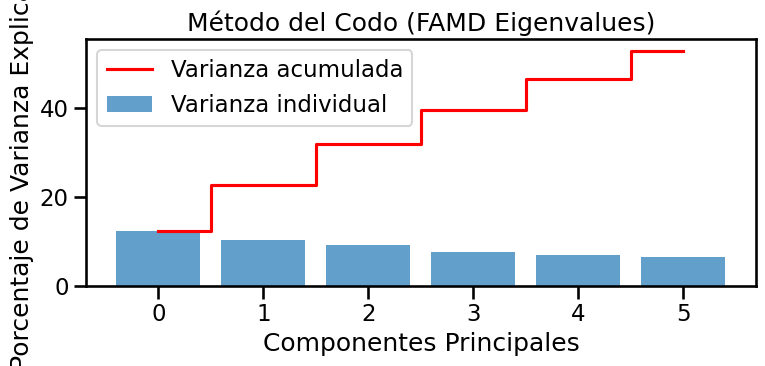

In [37]:
# Previsualización de la Varianza (Elbow Method)
eigenvalues = famd.eigenvalues_
explained_inertia = famd.percentage_of_variance_

plt.figure(figsize=(8, 4))
plt.bar(range(len(explained_inertia)), explained_inertia, alpha=0.7, align='center', label='Varianza individual')
plt.step(range(len(explained_inertia)), np.cumsum(explained_inertia), where='mid', label='Varianza acumulada', color='red')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Método del Codo (FAMD Eigenvalues)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Veamos la distribucion de la varianza en todas las componentes producidas por FAMD:

In [38]:
# 1. Pedimos un número de componentes superior al máximo teórico posible
# (FAMD truncará automáticamente en el número real de dimensiones)
famd_completo = prince.FAMD(n_components=15, random_state=42)
famd_completo.fit(X_cluster)

# 2. Obtener el número real de dimensiones generadas
num_dim_reales = len(famd_completo.percentage_of_variance_)
varianza_total = sum(famd_completo.percentage_of_variance_)

print(f"Dimensiones reales en el espacio FAMD: {num_dim_reales}")
print(f"Varianza acumulada total: {varianza_total:.2f}%")

# 3. Ver el aporte porcentual acumulado paso a paso
for i, pct in enumerate(famd_completo.percentage_of_variance_):
  acum = sum(famd_completo.percentage_of_variance_[: i + 1])
  print(f"Comp {i+1}: {pct:.2f}% | Acumulado: {acum:.2f}%")

Dimensiones reales en el espacio FAMD: 15
Varianza acumulada total: 97.17%
Comp 1: 12.33% | Acumulado: 12.33%
Comp 2: 10.35% | Acumulado: 22.68%
Comp 3: 9.23% | Acumulado: 31.91%
Comp 4: 7.68% | Acumulado: 39.59%
Comp 5: 6.96% | Acumulado: 46.56%
Comp 6: 6.47% | Acumulado: 53.03%
Comp 7: 5.90% | Acumulado: 58.94%
Comp 8: 5.89% | Acumulado: 64.82%
Comp 9: 5.88% | Acumulado: 70.70%
Comp 10: 5.59% | Acumulado: 76.29%
Comp 11: 5.35% | Acumulado: 81.64%
Comp 12: 4.78% | Acumulado: 86.42%
Comp 13: 4.15% | Acumulado: 90.57%
Comp 14: 3.34% | Acumulado: 93.91%
Comp 15: 3.26% | Acumulado: 97.17%


### Etapa 2: Agrupamiento Espacial Basado en Densidad (HDBSCAN)

Las coordenadas extraídas del FAMD (coordenadas_famd) son exclusivamente numéricas y ortogonales. Estas se utilizan como entrada idónea para distancias euclidianas en HDBSCAN.

In [39]:
import hdbscan

# Instanciar HDBSCAN
# min_cluster_size: El tamaño mínimo para considerar un grupo como "clúster" válido.
# Para ~8800 registros, 50 a 150 es un buen rango inicial para evitar micro-clústeres.
# min_samples: Controla el conservadurismo de la agrupación (mayor valor = más ruido/outliers descartados).
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=30,
    metric='euclidean',
    cluster_selection_method='eom' # Excess of Mass (busca clústeres más estables)
)

# Ajustar el modelo usando las coordenadas extraídas de FAMD
# Nota: Convertimos a numpy array para optimizar rendimiento
cluster_labels = clusterer.fit_predict(coordenadas_famd.to_numpy())

# Extraer resultados
X_cluster_resultados = X_cluster.copy()
X_cluster_resultados['Cluster_ID'] = cluster_labels
X_cluster_resultados['Probabilidad_Cluster'] = clusterer.probabilities_

# HDBSCAN etiqueta el ruido (outliers) con -1
print("Distribución de Clústeres:")
print(X_cluster_resultados['Cluster_ID'].value_counts())

Distribución de Clústeres:
Cluster_ID
-1     1696
 2      498
 30     446
 27     409
 28     332
 6      326
 21     310
 7      304
 16     287
 18     271
 29     260
 5      256
 13     251
 23     248
 22     224
 15     223
 9      217
 0      201
 8      196
 1      193
 3      192
 19     192
 14     181
 26     168
 25     157
 20     141
 4      132
 24     113
 10     112
 12     111
 11     108
 17     105
Name: count, dtype: int64


### **Explicación de los resultados obtenidos:**


Se observa que HDBSCAN está fallando estructuralmente para este conjunto de datos en el alto número de micro-clusters producidos y el alto porcentaje de entradas consideradas ruido (cerca del 20%).

Las variables categóricas (perfil_biocomercial y estado_caparazon) agregan múltiples dimensiones internas al modelo. Además, las variables de estacionalidad (mes_sin, mes_cos) y las continuas (profundidad_log, num_trampas_log, largo_caparazon, ano_continuo) tienen variaciones ortogonales (independientes entre sí).

En datos mixtos, la inercia total está naturalmente muy dispersa. Que 6 componentes expliquen el 45-48% de la varianza es normal en FAMD, pero significa que más del 50% de la variabilidad del dataset se omitió.

HDBSCAN asume que los datos están agrupados en "nubes densas" separadas por "valles vacíos". En el espacio vectorial de FAMD, esto no ocurre por dos razones:

FAMD proyecta las categorías (Macho_Comercial, Hembra_Ovigera, etc.) como puntos que tienden a separarse en bloques. Al combinar esto con variables continuas (como la profundidad o la talla), FAMD "estira" los datos creando un gradiente continuo con zonas intermedias con muy pocos puntos.

Al capturar menos del 50% de la varianza, los puntos en las 6 componentes continuas están repartidos de forma relativamente uniforme (sin picos de densidad nítidos). Cuando HDBSCAN no encuentra "cumbres de densidad" claras, se vuelve extremadamente inestable: o declara que todo es ruido o divide la nube en decenas de fragmentos idénticos.

Por lo expuesto anteriormente, descartamos la implementación de esta estrategia de clustering.



---
## Segunda Estrategia de Clustering: FAMD + Clustering Jerárquico de Ward

Esta implementación mantiene el tratamiendo inicial con FAMD, pero utiliza un modelo jerárquico en la segunda etapa.


### Etapa única: FAMD + WARD

Se incorpora una transformación logaritmica de las variables profundidad y num_trampas. Los algortimos son susceptibles a distribuciones con largas colas laterales, por lo que este reescalamiento resulta necesario.  

In [40]:
# Copia de seguridad del dataframe de entrenamiento
X_model = X_cluster.copy()

# Transformación logarítmica de la asimetría (Skewness)
# Usamos log1p (log(x + 1)) por seguridad matemática ante posibles ceros en los datos crudos
X_model['profundidad_log'] = np.log1p(X_model['profundidad'])
X_model['num_trampas_log'] = np.log1p(X_model['num_trampas'])

# 3. Descartamos las variables originales para no tener multicolinealidad
X_model = X_model.drop(columns=['profundidad', 'num_trampas'])

print("Asimetría corregida. Columnas listas para modelar.")

Asimetría corregida. Columnas listas para modelar.


In [41]:
import prince
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# El df no incluye 'localizacion' si tiene cardinalidad extrema

print("--- Ejecutando FAMD + Ward ---")

# Reducción de Dimensionalidad (FAMD)
# Buscamos capturar la varianza depurada de ruido
famd = prince.FAMD(
    n_components=5,
    n_iter=3,
    random_state=42,
    engine='sklearn'
)

# FAMD aplica su propio escalado internamente, le pasamos los datos crudos (con logaritmo)
coordenadas_famd = famd.fit_transform(X_model)

# En prince 0.21.0+, se utiliza percentage_of_variance_ en lugar de explained_inertia_
print(f"Varianza capturada por 5 componentes: {famd.percentage_of_variance_.sum()}%")

# Clustering Aglomerativo (Ward)
# n_clusters=5 obliga al algoritmo a devolver 5 bloques compactos, sin "ruido" (-1)
ward = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

# Entrenamiento y asignación
etiquetas_ward = ward.fit_predict(coordenadas_famd)
X_cluster['Cluster_Ward'] = etiquetas_ward

# Resultados
print("\nDistribución de Clústeres (Ward):")
print(X_cluster['Cluster_Ward'].value_counts().sort_index())

--- Ejecutando FAMD + Ward ---
Varianza capturada por 5 componentes: 46.77433528035812%

Distribución de Clústeres (Ward):
Cluster_Ward
0    1036
1    2574
2    2927
3     728
4    1595
Name: count, dtype: int64


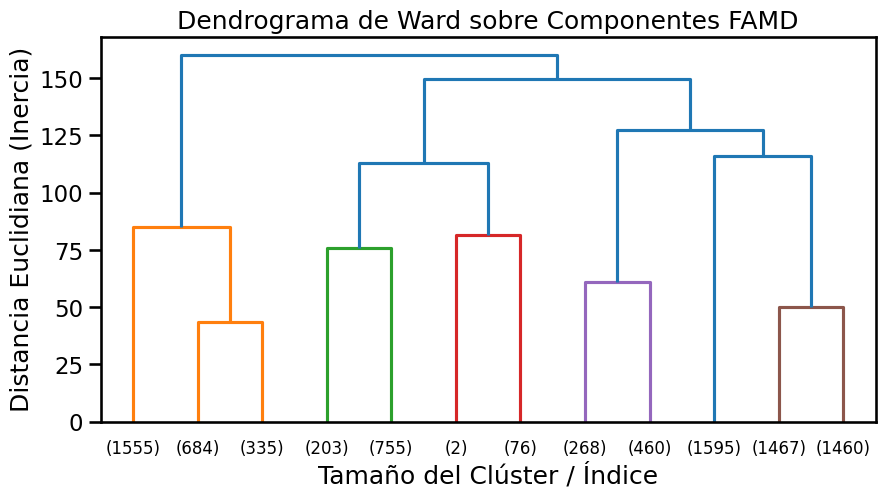

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calcular la matriz de enlaces sobre los componentes de FAMD
matriz_enlace = linkage(coordenadas_famd, method='ward')

# Graficar Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(matriz_enlace, truncate_mode='lastp', p=12)
plt.title('Dendrograma de Ward sobre Componentes FAMD')
plt.xlabel('Tamaño del Clúster / Índice')
plt.ylabel('Distancia Euclidiana (Inercia)')
plt.show()

## Tercera Estrategia de Clustering: K-Prototypes

Esta arquitectura es nativa para datos mixtos. Es la opción superior para reintegrar localizacion (incluso cruda), ya que K-Prototypes mide la distancia geográfica simplemente buscando si el nombre de la localización coincide o no (distancia de Hamming), sin multiplicar las dimensiones del dataset.

In [43]:
!pip install kmodes

### Etapa única

In [48]:
newX_model = df_individuos.drop(columns=['fecha','tipo','sexo',
                                        'madurez_sexual','latitud',
                                        'longitud','huevos']).copy()

# Transformación logarítmica de la asimetría (Skewness)
# Usamos log1p (log(x + 1)) por seguridad matemática ante posibles ceros en los datos crudos
newX_model['profundidad_log'] = np.log1p(newX_model['profundidad'])
newX_model['num_trampas_log'] = np.log1p(newX_model['num_trampas'])

# Descarte de las variables originales para no tener multicolinealidad
newX_model = newX_model.drop(columns=['profundidad', 'num_trampas'])

print("Asimetría corregida. Columnas listas para modelar.")


Asimetría corregida. Columnas listas para modelar.


In [49]:
newX_model.columns

Index(['localizacion', 'estado_caparazon', 'largo_caparazon',
       'perfil_biocomercial', 'mes_sin', 'mes_cos', 'ano_continuo',
       'profundidad_log', 'num_trampas_log'],
      dtype='object')

In [51]:
# Requiere instalación previa: pip install kmodes
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler

print("--- Ejecutando K-Prototypes ---")

# Definición estricta de tipos de columnas
# Asegúrate de listar los nombres exactos de tu DataFrame
columnas_numericas = [
    'largo_caparazon', 'mes_sin', 'mes_cos',
    'ano_continuo', 'profundidad_log', 'num_trampas_log'
]
# Incluimos localización porque K-Prototypes lo maneja eficientemente
columnas_categoricas = ['perfil_biocomercial', 'estado_caparazon', 'localizacion']

X_kp = newX_model[columnas_numericas + columnas_categoricas].copy()

# Estandarización obligatoria para numéricas (Z-score)
scaler = StandardScaler()
X_kp[columnas_numericas] = scaler.fit_transform(X_kp[columnas_numericas])

# Identificación de índices categóricos (requerido por el algoritmo)
indices_categoricos = [X_kp.columns.get_loc(col) for col in columnas_categoricas]

# Instanciar K-Prototypes
# init='Cao' es el método de inicialización más robusto para categorías
kp = KPrototypes(
    n_clusters=5,
    init='Cao',
    n_init=3, # Repite 3 veces y se queda con la mejor convergencia
    verbose=1,
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos del procesador
)

# Entrenamiento y asignación
# kp recibe un array de numpy
etiquetas_kp = kp.fit_predict(X_kp.values, categorical=indices_categoricos)
X_cluster['Cluster_KP'] = etiquetas_kp

# Resultados
print("\nDistribución de Clústeres (K-Prototypes):")
print(X_cluster['Cluster_KP'].value_counts().sort_index())

--- Ejecutando K-Prototypes ---
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 2

Distribución de Clústeres (K-Prototypes):
Cluster_KP
0    2738
1    2002
2    1058
3    1070
4    1992
Name: count, dtype: int64


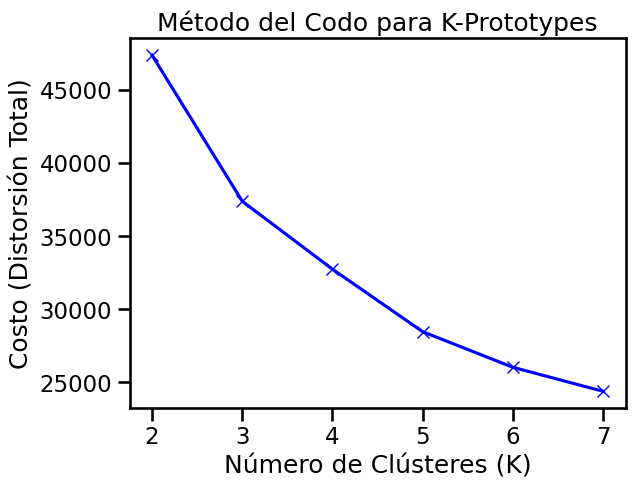

In [52]:
costos = []
K_rangos = range(2, 8)
for k in K_rangos:
  kp_test = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
  kp_test.fit(X_kp.values, categorical=indices_categoricos)
  costos.append(kp_test.cost_)

plt.plot(K_rangos, costos, 'bx-')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Costo (Distorsión Total)')
plt.title('Método del Codo para K-Prototypes')
plt.show()

## Inspeccion de clusters obtenidos

In [55]:
X_cluster.head()

,profundidad,estado_caparazon,largo_caparazon,num_trampas,perfil_biocomercial,mes_sin,mes_cos,ano_continuo,Cluster_Ward,Cluster_KP
rk,,,,,,,,,,
1,23.0,4,87.0,3.0,macho_comercial,0.5,0.866025,1996.0,0,2
2,23.0,3,77.1,3.0,hembra_ovigera_activa,0.5,0.866025,1996.0,0,2
3,23.0,3,74.6,3.0,hembra_ovigera_activa,0.5,0.866025,1996.0,0,2
4,23.0,3,75.6,3.0,macho_sublegal,0.5,0.866025,1996.0,0,2
5,23.0,3,75.6,3.0,hembra_ovigera_activa,0.5,0.866025,1996.0,0,2


In [62]:
# Unir las etiquetas resultantes al dataframe con variables interpretables

print("Análisis de Cluster obtenidos con K-Prototypes")
df_analisis_kp = X_cluster.copy()
df_analisis_kp['Cluster'] = etiquetas_kp  # o etiquetas_ward

# Perfil Numérico (Medianas por clúster)
perfil_numerico = df_analisis_kp.groupby('Cluster')[
    ['largo_caparazon', 'profundidad', 'num_trampas', 'ano_continuo']
].median()

# Perfil Comercial (Porcentaje de cada perfil biocomercial por clúster)
perfil_comercial = (
    pd.crosstab(
        df_analisis_kp['Cluster'],
        df_analisis_kp['perfil_biocomercial'],
        normalize='index',
    )
    * 100
)

# Unir ambos perfiles para la toma de decisiones
resumen_clusters = pd.concat([perfil_numerico, perfil_comercial], axis=1).round(
    2
)
resumen_clusters

Análisis de Cluster obtenidos con K-Prototypes


,largo_caparazon,profundidad,num_trampas,ano_continuo,hembra_anovigera,hembra_ovigera_activa,hembra_post_eclosion,hembra_sin_evaluar,macho_comercial,macho_sublegal
Cluster,,,,,,,,,,
0,71.55,32.0,4.0,1997.75,12.05,38.97,6.65,0.55,7.27,34.51
1,73.90,24.0,1.0,1996.50,9.14,22.08,2.05,0.85,27.72,38.16
2,76.70,32.0,3.0,1996.00,5.95,42.06,7.56,3.31,23.35,17.77
3,75.20,22.0,10.0,1996.50,10.47,14.86,2.06,0.28,33.83,38.50
4,85.40,33.0,2.5,1998.75,2.71,6.07,2.16,0.10,73.34,15.61


In [63]:
# @title
# Unir las etiquetas resultantes al dataframe con variables interpretables

print("Análisis de Cluster obtenidos con WARD")
df_analisis_wd = X_cluster.copy()
df_analisis_wd['Cluster'] = etiquetas_ward  # o etiquetas_ward

# Perfil Numérico (Medianas por clúster)
perfil_numerico_wd = df_analisis_wd.groupby('Cluster')[
    ['largo_caparazon', 'profundidad', 'num_trampas', 'ano_continuo']
].median()

# Perfil Comercial (Porcentaje de cada perfil biocomercial por clúster)
perfil_comercial_wd = (
    pd.crosstab(
        df_analisis_wd['Cluster'],
        df_analisis_wd['perfil_biocomercial'],
        normalize='index',
    )
    * 100
)

# Unir ambos perfiles para la toma de decisiones
resumen_clusters_wd = pd.concat([perfil_numerico_wd, perfil_comercial_wd],
                             axis=1).round(2)
resumen_clusters_wd

Análisis de Cluster obtenidos con WARD


,largo_caparazon,profundidad,num_trampas,ano_continuo,hembra_anovigera,hembra_ovigera_activa,hembra_post_eclosion,hembra_sin_evaluar,macho_comercial,macho_sublegal
Cluster,,,,,,,,,,
0,76.60,30.0,3.00,1996.00,6.18,43.34,1.25,6.95,24.13,18.15
1,86.80,28.0,2.75,1997.75,0.00,0.00,0.00,0.00,100.00,0.00
2,72.00,30.0,3.00,1997.75,12.78,43.80,0.00,0.00,0.00,43.42
3,72.85,33.0,3.00,1997.50,7.69,32.42,48.76,0.00,0.00,11.13
4,70.40,22.0,1.80,1996.50,15.55,16.74,0.00,0.00,0.00,67.71


### Protocolo de Validación

El siguiente script calcula la comparación estadística directa entre FAMD + Ward y K-Prototypes usando el espacio continuo de FAMD como métrica de referencia compartida:

In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# Definición del espacio métrico de evaluación (Componentes FAMD)
X_eval = coordenadas_famd.to_numpy()

# Evaluación de FAMD + Ward
sil_ward = silhouette_score(X_eval, etiquetas_ward)
db_ward = davies_bouldin_score(X_eval, etiquetas_ward)
ch_ward = calinski_harabasz_score(X_eval, etiquetas_ward)

# Evaluación de K-Prototypes sobre la misma proyección espacial
sil_kp = silhouette_score(X_eval, etiquetas_kp)
db_kp = davies_bouldin_score(X_eval, etiquetas_kp)
ch_kp = calinski_harabasz_score(X_eval, etiquetas_kp)

# Tabla comparativa de respaldo técnico
metricas_df = pd.DataFrame({
    'Métrica': [
        'Coeficiente Silueta (↑)',
        'Davies-Bouldin (↓)',
        'Calinski-Harabasz (↑)',
    ],
    'FAMD + Ward': [sil_ward, db_ward, ch_ward],
    'K-Prototypes': [sil_kp, db_kp, ch_kp],
})

print("=== EVALUACIÓN COMPARATIVA DE MODELOS DE CLUSTERING ===")
print(metricas_df.to_string(index=False))

=== EVALUACIÓN COMPARATIVA DE MODELOS DE CLUSTERING ===
                Métrica  FAMD + Ward  K-Prototypes
Coeficiente Silueta (↑)     0.364849      0.175160
     Davies-Bouldin (↓)     1.064701      4.766713
  Calinski-Harabasz (↑)  2717.399589   1596.705846


### Prueba de Estabilidad Estadísticas por Submuestreo (Bootstrapping / ARI)

Para descartar que los clústeres sean producto del azar o de la inicialización, se realiza una prueba de estabilidad mediante el Índice Rand Ajustado (ARI) sobre 30 submuestras aleatorias (80% del dataset):

In [65]:
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

# Implementación para WARD linkage

estabilidad_scores = []

# Iteración de submuestreo para verificar reproducibilidad
for i in range(20):
  # Muestreo aleatorio del 80%
  idx_sub = resample(
      np.arange(len(X_eval)), n_samples=int(0.8 * len(X_eval)), random_state=i
  )

  X_sub = X_eval[idx_sub]

  # Re-entrenar Ward en la submuestra
  ward_sub = AgglomerativeClustering(n_clusters=5, linkage='ward')
  labels_sub = ward_sub.fit_predict(X_sub)

  # Comparar las etiquetas originales recortadas con las nuevas usando ARI
  score_ari = adjusted_rand_score(etiquetas_ward[idx_sub], labels_sub)
  estabilidad_scores.append(score_ari)

print(
    f"Estabilidad Media (ARI) FAMD + Ward: {np.mean(estabilidad_scores):.3f}"
    f" (± {np.std(estabilidad_scores):.3f})"
)

Estabilidad Media (ARI) FAMD + Ward: 0.876 (± 0.124)


In [67]:
import numpy as np
import pandas as pd
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

# Implementación para K-Prototypes

estabilidad_scores_kp = []

# Matriz de datos de K-Prototypes (X_kp) e índices categóricos predefinidos
X_kp_values = X_kp.values
n_muestras_sub = int(0.8 * len(X_kp))

for i in range(20):
  # Muestreo aleatorio del 80% de las filas
  idx_sub = resample(
      np.arange(len(X_kp)), n_samples=n_muestras_sub, random_state=i
  )

  X_sub = X_kp_values[idx_sub]

  # Re-entrenar K-Prototypes sobre la submuestra
  kp_sub = KPrototypes(
      n_clusters=5,
      init='Cao',
      n_init=1,
      random_state=i,  # Varía la semilla para probar sensibilidad a inicialización
      n_jobs=-1,
  )

  labels_sub = kp_sub.fit_predict(X_sub, categorical=indices_categoricos)

  # Comparar etiquetas originales recortadas vs. etiquetas del modelo en submuestra
  score_ari = adjusted_rand_score(etiquetas_kp[idx_sub], labels_sub)
  estabilidad_scores_kp.append(score_ari)

print(
    f"Estabilidad Media (ARI) K-Prototypes: {np.mean(estabilidad_scores_kp):.3f}"
    f" (± {np.std(estabilidad_scores_kp):.3f})"
)

Estabilidad Media (ARI) K-Prototypes: 0.853 (± 0.155)


### Inferencia Espacial Post-Hoc

En función de las métricas de validación anteriores, se opta por trabajar con la estrategia FAMD + WARD

Para traducir los 5 clústeres abstractos a mapa y territorio, se proyectan las etiquetas resultantes sobre las variables de ubicación que quedaron fuera de la matriz $X$:

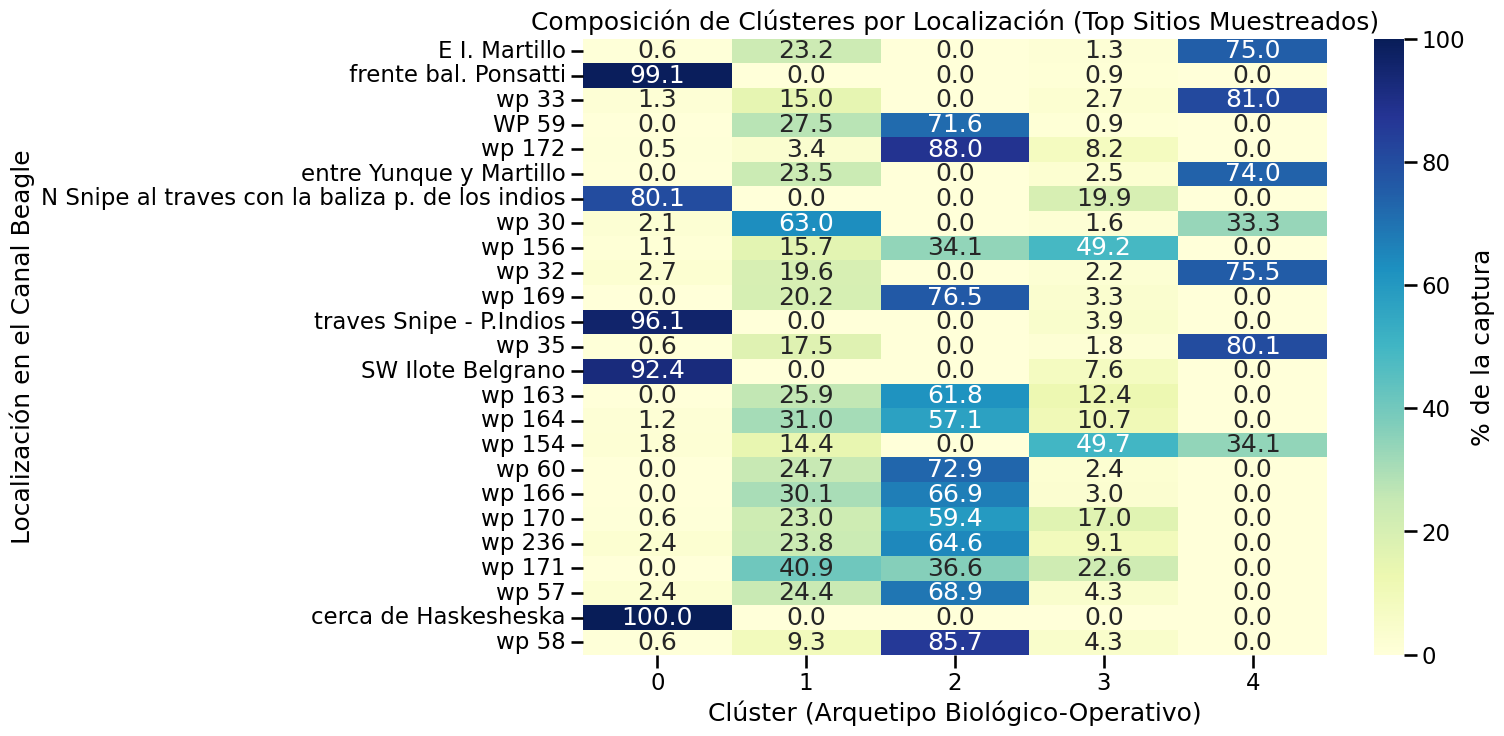

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Unir las etiquetas del clúster a los metadatos geográficos originales
df_espacial = df_individuos[['localizacion', 'latitud', 'longitud']].copy()
df_espacial['Cluster'] = etiquetas_ward

# Matriz de Composición Espacial: Porcentaje de cada Clúster por Localización
# Muestra qué arquetipos dominan en cada sitio de pesca
composicion_sitios = pd.crosstab(
    df_espacial['localizacion'],
    df_espacial['Cluster'],
    normalize='index',  # Muestra proporciones (0 a 1)
) * 100

# Filtrar solo localizaciones con representatividad muestral (> 30 individuos)
muestras_por_sitio = df_espacial['localizacion'].value_counts()
sitios_validos = muestras_por_sitio[muestras_por_sitio >= 30].index
composicion_sitios_filtrada = composicion_sitios.loc[sitios_validos]

# Visualizar las Top 15 localizaciones más representativas
plt.figure(figsize=(12, 8))
sns.heatmap(
    composicion_sitios_filtrada.head(25),
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': '% de la captura'},
)
plt.title('Composición de Clústeres por Localización (Top Sitios Muestreados)')
plt.xlabel('Clúster (Arquetipo Biológico-Operativo)')
plt.ylabel('Localización en el Canal Beagle')
plt.show()

Interpretación de la Inferencia Espacial

A partir de este cruce, las recomendaciones de manejo espacial pueden ser:

Zonas Comercial y Operativamente Atractivas: Aquellas localizaciones donde el Clúster Comercial (machos $\ge 80\text{ mm}$ en profundidad adecuada) represente un porcentaje dominante de las capturas del sitio (ej. $> 70\%$).

Zonas de Resguardo Biológico Preventivo: Aquellas localizaciones donde predomine un clúster caracterizado por alta concentración de hembras u organismos sub-legales, señalando áreas donde la actividad extractiva generaría un elevado volumen de descarte o impacto reproductivo.

Mapeo Cartográfico (Cartografía 88% GPS): Para los registros que cuentan con coordenadas continuas (latitud/longitud), se grafican en un mapa GIS o con geopandas, coloreando los puntos según su Cluster. Esto permite visualizar los "parches" o gradientes continuos de distribución a lo largo del Canal Beagle.

### Tabla Pareteada (Top 10 Sitios por Clúster)

El siguiente script calcula la participación individual y la participación acumulada de las 10 localizaciones principales para cada uno de los 5 clústeres:

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Unir etiquetas de clúster a la localización original
df_pareto = pd.DataFrame(
    {'localizacion': df_individuos['localizacion'], 'Cluster': etiquetas_ward}
)

# Conteo absoluto de capturas por (Cluster, Localización)
conteo = (
    df_pareto.groupby(['Cluster', 'localizacion'])
    .size()
    .reset_index(name='conteo')
)

# Calcular porcentaje sobre el total de cada Clúster y la suma acumulada
conteo['total_cluster'] = conteo.groupby('Cluster')['conteo'].transform('sum')
conteo['pct_cluster'] = (conteo['conteo'] / conteo['total_cluster']) * 100

# Ordenar descendentemente por clúster y porcentaje
conteo = conteo.sort_values(['Cluster', 'pct_cluster'], ascending=[True, False])

# Calcular porcentaje acumulado por clúster
conteo['pct_acumulado'] = conteo.groupby('Cluster')['pct_cluster'].cumsum()

# Filtrar los 10 puntos principales por clúster
top10_por_cluster = conteo.groupby('Cluster').head(10).copy()

# Visualizar tabla resumida
print("=== TOP 10 PUNTOS DE EXTRACCIÓN POR CLÚSTER ===")
for c in sorted(top10_por_cluster['Cluster'].unique()):
  sub = top10_por_cluster[top10_por_cluster['Cluster'] == c]
  acum_total = sub['pct_acumulado'].iloc[-1]
  print(
      f"\n--- CLÚSTER {c} (Top 10 representan el {acum_total:.1f}% de la"
      " extracción del clúster) ---"
  )
  print(
      sub[['localizacion', 'conteo', 'pct_cluster', 'pct_acumulado']].to_string(
          index=False
      )
  )

=== TOP 10 PUNTOS DE EXTRACCIÓN POR CLÚSTER ===

--- CLÚSTER 0 (Top 10 representan el 97.2% de la extracción del clúster) ---
                                    localizacion  conteo  pct_cluster  pct_acumulado
                            frente bal. Ponsatti     232    22.393822      22.393822
                         traves Snipe - P.Indios     172    16.602317      38.996139
                            cerca de Haskesheska     163    15.733591      54.729730
                               SW Ilote Belgrano     157    15.154440      69.884170
N Snipe al traves con la baliza p. de los indios     153    14.768340      84.652510
                 S islote Belgrano/punta navarro     113    10.907336      95.559846
                                           wp 32       5     0.482625      96.042471
                                          wp 236       4     0.386100      96.428571
                                           wp 30       4     0.386100      96.814672
                        

### Representación Gráfica (Grid de Gráficos de Barra por Clúster) y otras verificaciones

Esta visualización genera un panel de 5 subgráficos donde la barra representa el porcentaje del sitio y la línea roja señala el acumulado acumulativo de extracción:

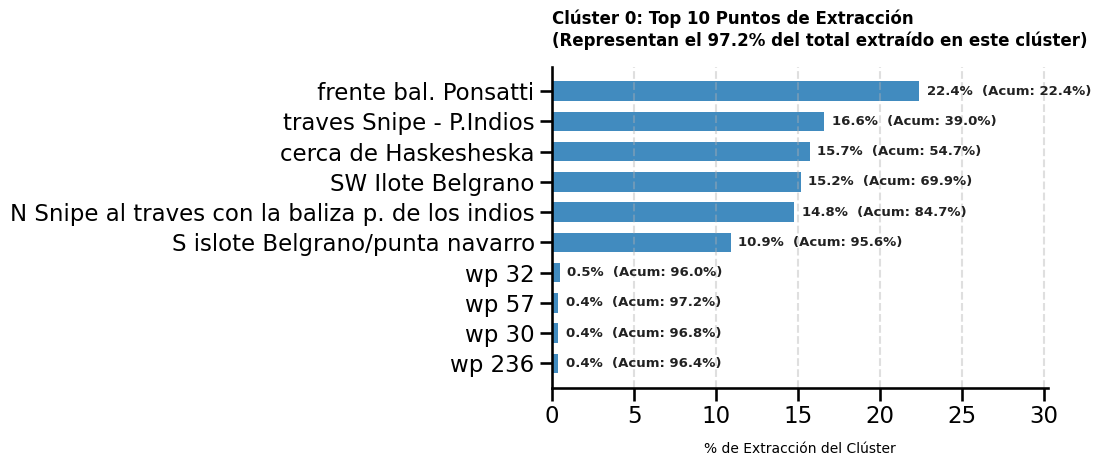

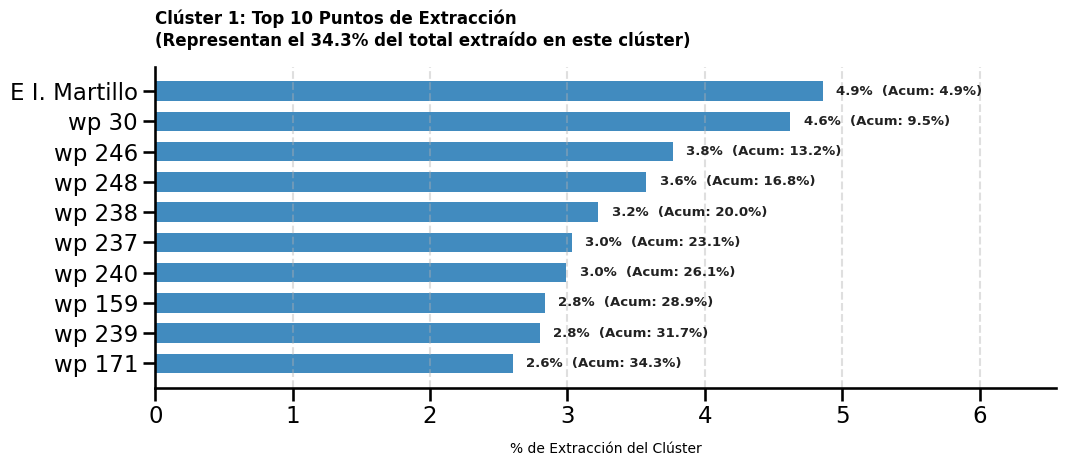

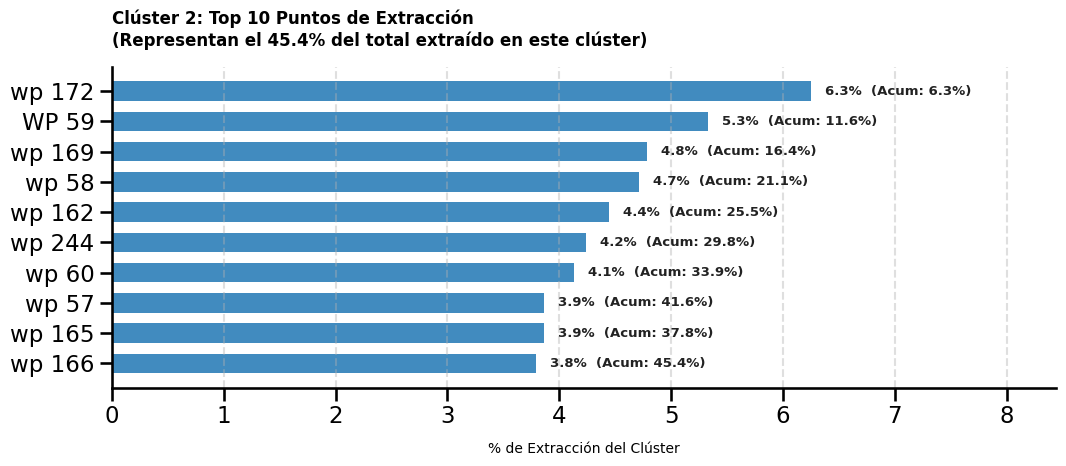

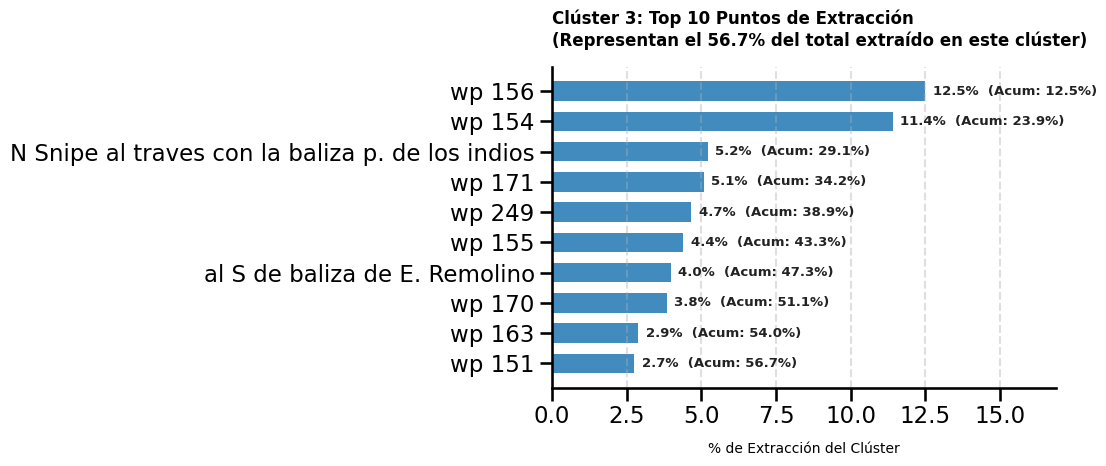

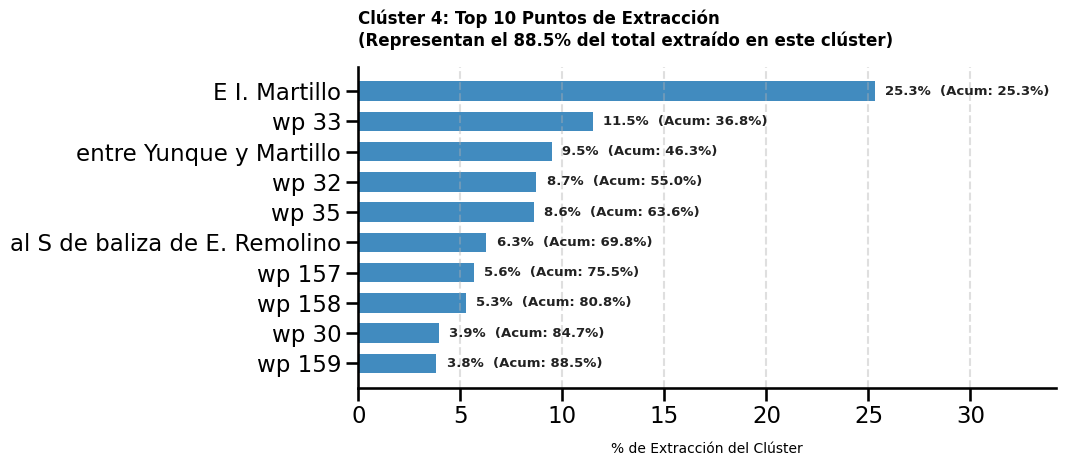

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preparación y cálculo acumulado por localización
df_pareto = pd.DataFrame(
    {'localizacion': df_individuos['localizacion'], 'Cluster': etiquetas_ward}
)

conteo = (
    df_pareto.groupby(['Cluster', 'localizacion'])
    .size()
    .reset_index(name='conteo')
)
conteo['total_cluster'] = conteo.groupby('Cluster')['conteo'].transform('sum')
conteo['pct_cluster'] = (conteo['conteo'] / conteo['total_cluster']) * 100

# Ordenar por Clúster y % descendente para calcular acumulado
conteo = conteo.sort_values(
    ['Cluster', 'pct_cluster'], ascending=[True, False]
)
conteo['pct_acumulado'] = conteo.groupby('Cluster')['pct_cluster'].cumsum()

# Filtrar Top 10 por clúster
top10_por_cluster = conteo.groupby('Cluster').head(10).copy()

# Generar una figura independiente por cada clúster
clusters_unicos = sorted(top10_por_cluster['Cluster'].unique())

for c in clusters_unicos:
  data_c = top10_por_cluster[top10_por_cluster['Cluster'] == c].copy()

  # Ordenar de menor a mayor para que en barras horizontales el #1 quede arriba
  data_c = data_c.sort_values('pct_cluster', ascending=True)
  pct_total_top10 = data_c['pct_cluster'].sum()

  # Crear figura amplia individual
  fig, ax = plt.subplots(figsize=(11, 5))

  # Dibujar barras horizontales
  bars = ax.barh(
      data_c['localizacion'],
      data_c['pct_cluster'],
      color='#1f77b4',
      height=0.65,
      alpha=0.85,
  )

  # Anotar datos al final de cada barra: % individual + % acumulado
  max_pct = data_c['pct_cluster'].max()
  for bar, pct, acum in zip(
      bars, data_c['pct_cluster'], data_c['pct_acumulado']
  ):
    width = bar.get_width()
    ax.text(
        width + (max_pct * 0.02),  # Pequeño desplazamiento a la derecha
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%  (Acum: {acum:.1f}%)',
        va='center',
        ha='left',
        fontsize=9.5,
        fontweight='bold',
        color='#222222',
    )

  # Estética y límites
  ax.set_xlim(0, max_pct * 1.35)  # Margen derecho para que quepa el texto
  ax.set_xlabel('% de Extracción del Clúster', fontsize=10, labelpad=10)
  ax.set_title(
      f'Clúster {c}: Top 10 Puntos de Extracción\n'
      f'(Representan el {pct_total_top10:.1f}% del total extraído en este'
      ' clúster)',
      fontsize=12,
      fontweight='bold',
      loc='left',
      pad=15,
  )

  # Limpieza de bordes para enfoque visual limpio
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.grid(axis='x', linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()

Verificación sobre top10_por_cluster, identifica las localizaciones que se repiten en dos o más clústeres y genera tanto un detalle cuantitativo como una matriz de coincidencia:

In [71]:
import pandas as pd

# Identificar localizaciones que aparecen más de una vez en el Top 10 global
frecuencia_sitios = top10_por_cluster['localizacion'].value_counts()
sitios_compartidos = frecuencia_sitios[frecuencia_sitios > 1].index.tolist()

if len(sitios_compartidos) == 0:
  print(
      '✅ RESULTADO: El Top 10 de puntos de extracción es 100% MUTUAMENTE'
      ' EXCLUYENTE entre los 5 clústeres.'
  )
else:
  print(
      f'⚠️ ATENCIÓN: Se detectaron {len(sitios_compartidos)} localizaciones'
      ' compartidas en el Top 10 de múltiples clústeres.\n'
  )

  # Filtrar el dataframe para aislar las localizaciones compartidas
  df_compartidos = top10_por_cluster[
      top10_por_cluster['localizacion'].isin(sitios_compartidos)
  ].copy()

  # Ordenar para facilitar la lectura
  df_compartidos = df_compartidos.sort_values(
      by=['localizacion', 'pct_cluster'], ascending=[True, False]
  )

  # Vista matricial de la contribución (%) por clúster
  matriz_pivote = df_compartidos.pivot_table(
      index='localizacion', columns='Cluster', values='pct_cluster', aggfunc='sum'
  ).fillna(0)

  # Añadir columna con la cantidad de clústeres en los que impacta
  matriz_pivote['Clústeres_Impactados'] = (matriz_pivote > 0).sum(axis=1)

  print('=== MATRIZ DE APORTACIÓN (%) DE PUNTOS COMPARTIDOS ===')
  print(matriz_pivote.round(2).to_string())

⚠️ ATENCIÓN: Se detectaron 8 localizaciones compartidas en el Top 10 de múltiples clústeres.

=== MATRIZ DE APORTACIÓN (%) DE PUNTOS COMPARTIDOS ===
Cluster                                               0     1     2     3      4  Clústeres_Impactados
localizacion                                                                                          
E I. Martillo                                      0.00  4.86  0.00  0.00  25.33                     2
N Snipe al traves con la baliza p. de los indios  14.77  0.00  0.00  5.22   0.00                     2
al S de baliza de E. Remolino                      0.00  0.00  0.00  3.98   6.27                     2
wp 159                                             0.00  2.84  0.00  0.00   3.82                     2
wp 171                                             0.00  2.60  0.00  5.08   0.00                     2
wp 30                                              0.39  4.62  0.00  0.00   3.95                     3
wp 32                      

In [73]:


print("Análisis de Cluster obtenidos con WARD")
df_analisis_wd = X_cluster.copy()
df_analisis_wd['Cluster'] = etiquetas_ward  # o etiquetas_ward

# Perfil Numérico (Medianas por clúster)
perfil_numerico_wd = df_analisis_wd.groupby('Cluster')[
    ['largo_caparazon', 'profundidad', 'num_trampas', 'ano_continuo']
].median()

# Perfil Comercial (Porcentaje de cada perfil biocomercial por clúster)
perfil_comercial_wd = (
    pd.crosstab(
        df_analisis_wd['Cluster'],
        df_analisis_wd['perfil_biocomercial'],
        normalize='index',
    )
    * 100
)

# Unir ambos perfiles para la toma de decisiones
resumen_clusters_wd = pd.concat([perfil_numerico_wd, perfil_comercial_wd],
                             axis=1).round(2)
resumen_clusters_wd

Análisis de Cluster obtenidos con WARD


,largo_caparazon,profundidad,num_trampas,ano_continuo,hembra_anovigera,hembra_ovigera_activa,hembra_post_eclosion,hembra_sin_evaluar,macho_comercial,macho_sublegal
Cluster,,,,,,,,,,
0,76.60,30.0,3.00,1996.00,6.18,43.34,1.25,6.95,24.13,18.15
1,86.80,28.0,2.75,1997.75,0.00,0.00,0.00,0.00,100.00,0.00
2,72.00,30.0,3.00,1997.75,12.78,43.80,0.00,0.00,0.00,43.42
3,72.85,33.0,3.00,1997.50,7.69,32.42,48.76,0.00,0.00,11.13
4,70.40,22.0,1.80,1996.50,15.55,16.74,0.00,0.00,0.00,67.71


Estudio de la composición de cada cluster en función de la fecha del evento de pesca registrado.

In [72]:
import pandas as pd

# Asegurar que tenemos la columna de fecha original unida a las etiquetas del clúster
# (Reemplaza 'fecha' por el nombre exacto de tu columna de fecha original)
df_analisis_fechas = pd.DataFrame({
    'fecha': df_individuos['fecha'],
    'Cluster': etiquetas_ward  # o df_analisis['Cluster']
})

# Generar la tabla de contingencia normalizada por COLUMNAS (Clústeres)
# normalize='columns' calcula el % de cada fecha dentro de la masa total de ese clúster
matriz_fechas_pct = pd.crosstab(
    index=df_analisis_fechas['fecha'],
    columns=df_analisis_fechas['Cluster'],
    normalize='columns'
) * 100

# Formatear a 2 decimales para lectura limpia
matriz_fechas_formateada = matriz_fechas_pct.round(2)

# Verificación de la suma vertical por clúster (debe ser exactamente 100% por columna)
print("--- VERIFICACIÓN DE SUMAS POR COLUMNA (CLÚSTER) ---")
print(matriz_fechas_pct.sum(axis=0).round(2).to_dict())

# Visualizar la tabla de composición
print("\n=== COMPOSICIÓN PORCENTUAL DE FECHAS POR CLÚSTER (%) ===")
print(matriz_fechas_formateada)

--- VERIFICACIÓN DE SUMAS POR COLUMNA (CLÚSTER) ---
{0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0, 4: 100.0}

=== COMPOSICIÓN PORCENTUAL DE FECHAS POR CLÚSTER (%) ===
Cluster       0      1      2      3      4
fecha                                      
ene_96    79.83   0.00   0.00   9.34   0.00
abril_96  15.73   0.00   0.00   0.00   0.00
jul_96     1.74  17.44   0.00   4.67  70.85
oct_96     0.68  13.29  31.02   8.10   0.00
jul_97     0.77  18.45   6.56  42.99  29.15
oct_97     0.68  16.51  41.24  20.88   0.00
oct_98     0.58  34.30  21.18  14.01   0.00


=== GENERANDO HISTOGRAMAS PARA VARIABLES CONTINUAS ===


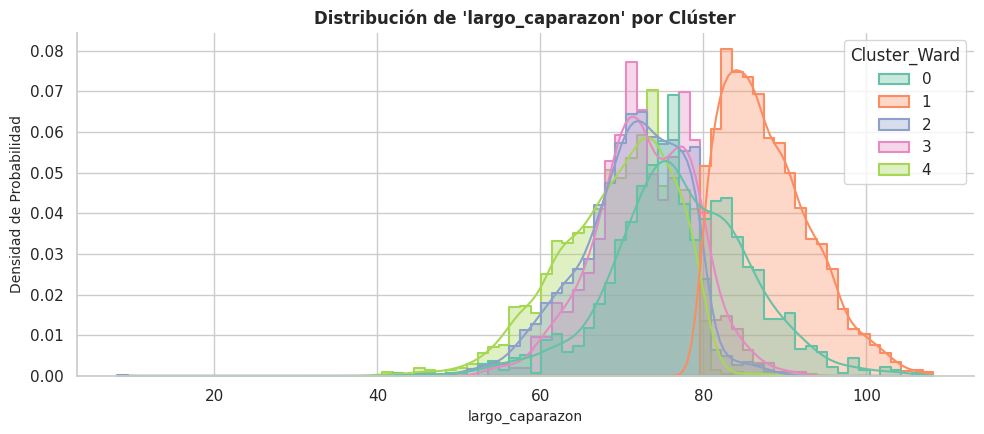

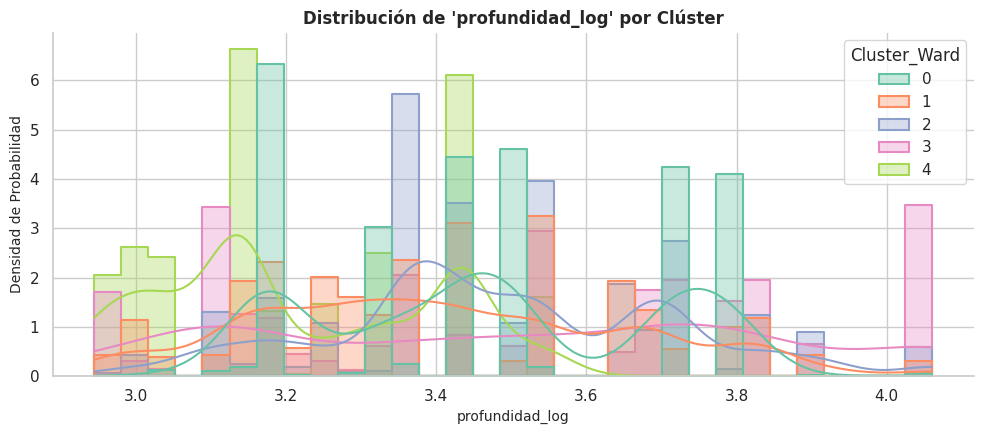

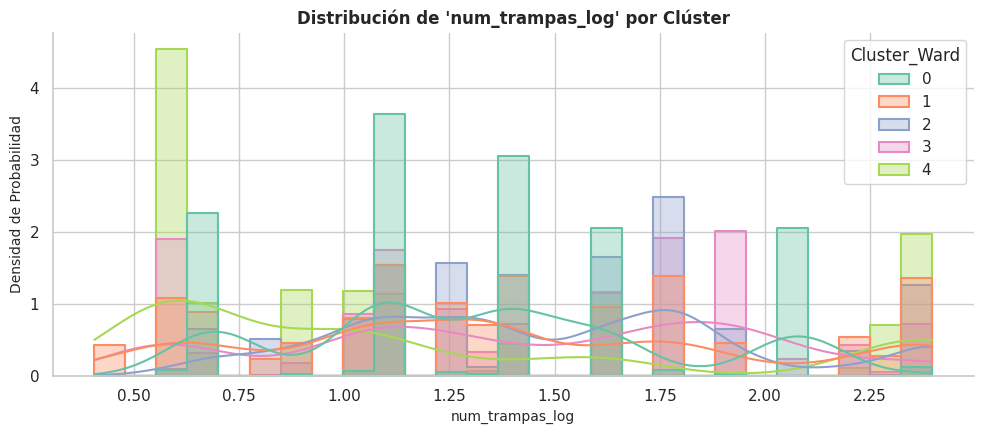

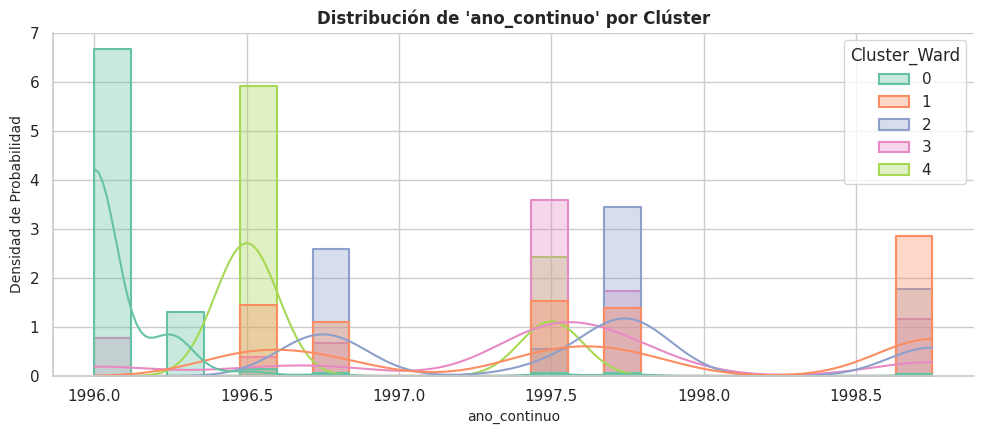

=== GENERANDO GRÁFICOS DE BARRAS PARA VARIABLES CATEGÓRICAS ===


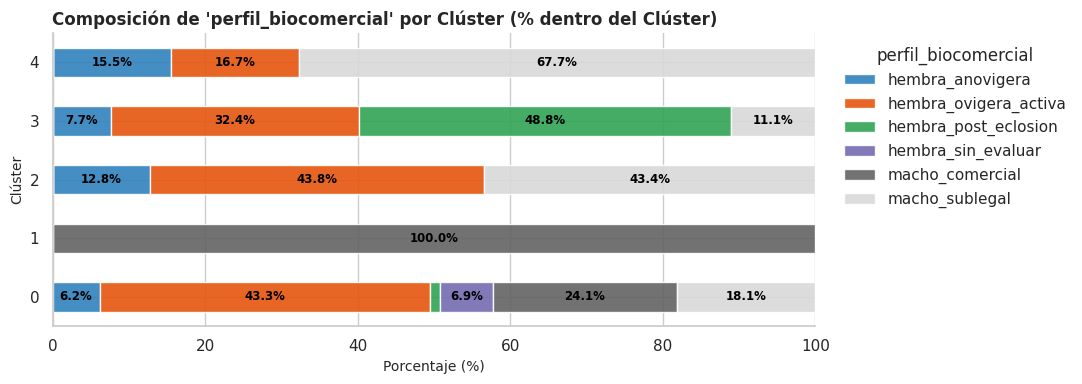

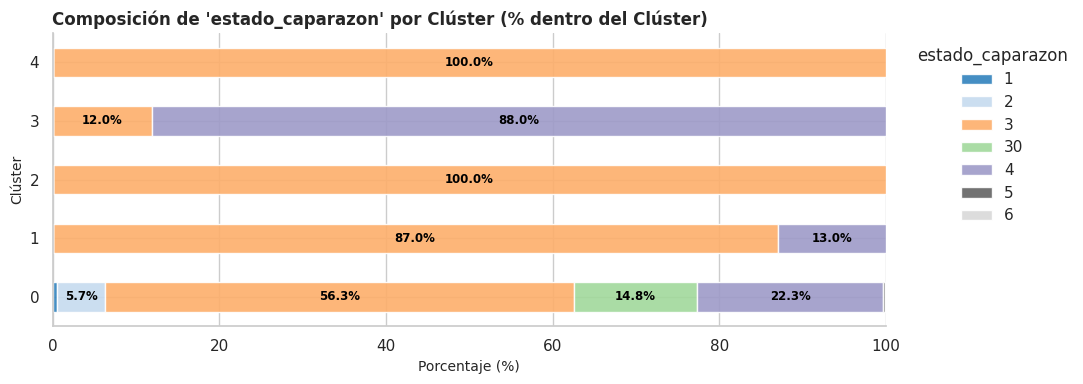

In [74]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración visual global
sns.set_theme(style="whitegrid")


def analizar_distribuciones_clusters(
    df, num_cols, cat_cols, cluster_col="Cluster"
):
  """Genera histogramas para variables continuas y gráficos de barras normalizados

  para variables categóricas, comparando la distribución de cada clúster.
  """
  clusters = sorted(df[cluster_col].unique())
  palette = sns.color_palette("Set2", n_colors=len(clusters))

  # ---------------------------------------------------------
  # 1. HISTOGRAMAS (VARIABLES CONTINUAS)
  # ---------------------------------------------------------
  print("=== GENERANDO HISTOGRAMAS PARA VARIABLES CONTINUAS ===")
  for col in num_cols:
    fig, ax = plt.subplots(figsize=(10, 4.5))

    # stat='density' y common_norm=False permiten comparar formas aunque los clústeres tengan distinto N
    sns.histplot(
        data=df,
        x=col,
        hue=cluster_col,
        element="step",
        stat="density",
        common_norm=False,
        kde=True,
        palette=palette,
        ax=ax,
        alpha=0.35,
        linewidth=1.5,
    )

    ax.set_title(
        f"Distribución de '{col}' por Clúster", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

  # ---------------------------------------------------------
  # 2. BARRAS NORMALIZADAS (VARIABLES CATEGÓRICAS)
  # ---------------------------------------------------------
  print("=== GENERANDO GRÁFICOS DE BARRAS PARA VARIABLES CATEGÓRICAS ===")
  for col in cat_cols:
    # Matriz de contingencia: % que representa cada categoría DENTRO de cada clúster
    cross_pct = (
        pd.crosstab(index=df[cluster_col], columns=df[col], normalize="index")
        * 100
    )

    fig, ax = plt.subplots(figsize=(11, max(4, len(clusters) * 0.8)))

    # Dibujar barras apiladas al 100%
    cross_pct.plot(
        kind="barh", stacked=True, ax=ax, colormap="tab20c", alpha=0.9
    )

    ax.set_title(
        f"Composición de '{col}' por Clúster (% dentro del Clúster)",
        fontsize=12,
        fontweight="bold",
        loc="left",
    )
    ax.set_xlabel("Porcentaje (%)", fontsize=10)
    ax.set_ylabel("Clúster", fontsize=10)
    ax.set_xlim(0, 100)

    # Anotar porcentaje directamente dentro de los segmentos de barra
    for p in ax.patches:
      width, height = p.get_width(), p.get_height()
      if width > 5:  # Mostrar texto solo en segmentos mayores al 5%
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{width:.1f}%",
            ha="center",
            va="center",
            fontsize=8.5,
            color="black",
            fontweight="bold",
        )

    ax.legend(
        title=col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# =========================================================
# EJECUCIÓN DEL SCRIPT
# =========================================================

# Definición de columnas según la estructura del dataset
columnas_continuas = [
    "largo_caparazon",
    "profundidad_log",
    "num_trampas_log",
    "ano_continuo",
]

columnas_categoricas = ["perfil_biocomercial", "estado_caparazon"]

# Unir etiquetas del clúster Ward al DataFrame de análisis
df_analisis = X_model.copy()
df_analisis["Cluster_Ward"] = etiquetas_ward

# Llamada a la función
analizar_distribuciones_clusters(
    df=df_analisis,
    num_cols=columnas_continuas,
    cat_cols=columnas_categoricas,
    cluster_col="Cluster_Ward",
)

## Resultados y discusiones

La estrategia de clustering implementada FAMD + WARD demuestra ser una elección sólida sobre la cuál construir nuestras conclusiones del trabajo.

Algunos de los 5 clusters obtenidos presentan características muy especificas que los distinguen claramente de los demás, mientras que otros tienen límites más difusos. Se describen a continuación:

- Cluster 0: Posee 1036 individuos, representando el 11.7% del total. Más del 95% de individuos corresponde a campañas de la primera mitad de 1996. Hay una presencia fuerte de hembras ovígeras activas (43.3%) y machos (42.2%), siendo un 24.1% correspondiente a machos comerciales. Sólo el 1.3% de registros corresponde a hembras en estadíos de post eclosión. Importante destacar que solo 6 puntos de extracción concentran el 95.6% de los registros. La distribución del largo de caparazón se aproxima a una normal y no muestra grandes sesgos laterales.

- Cluster 1: Con 2574 individuos, representa el 29.1% del total. Este cluster posee únicamente machos comerciales. Los registros se distribuyen interanualmente en las campañas de julio y octubre, siendo octubre del 98 la más significativa. El espectro de profundidades de extracción es más amplio, lo cual condice con una descentralización de la pesca. Pues los 10 puntos de extracción más representativos del conjunto representan únicamente el 34.3% del cluster, sin mostrar grandes concentraciones en ningún punto. La distribución de talla se ve claramente sesgada a derecha, pues el valor de corte es 80cm para machos legales.

- Cluster 2: Representa el 33% del total de datos. La talla se observa sesgada a izquierda, pues incluye individuos sexualmente inmaduros. El 43.8% de individuos son hembras ovígeras activas, y el 43.4% son machos sublegales. El resto son hembras sin huevos. En la distribución temporal tienen muy fuerte presencia los meses de octubre: el 97 con 41%, el 96 con 31.2% y el 98 con 21.2%. los 10 puntos de extracción más representativos representan el 45.5% del cluster.

- Cluster 3: Representa solo el 8% de los datos. Cerca del 90% de registros son hembras, donde el 48.8% están en estadíos de post-eclosión y el 32.4% son hembras ovígeras activas. La distribución de tallas no presenta sesgos, pero la presencia de machos sublegales (11%) y hembras maduras conforman una distribución bimodal en lugar de una gaussiana. LAs campañas más significativas son julio del 97 (42%) y octubre del 97 (21%). Las 10 ubicaciones más significativas representan el 56.7% de los datos, de los cuales los primeros 2 aportan cerca de 24% (wp156 y wp154).

- Cluster 4: Representa el 18% del total de datos. Hay una presencia muy fuerte de machos sublegales (67,7%). Los demás registros están balanceados en hembras anovígeras y hembras ovígeras activas. Los registros corresponden a las campañas de julio del 96 (70.9%) y julio del 97. Las 10 ubicaciones más significativas sintetizan el 88.5% de los datos. Llama la atención que en E. I. Martillo se encuentre el 25.3% del cluster, mientras que la segunda ubicacion mas significativa represente el 11.5%.

Resumen
---

- **Cluster 0** -> agrupado por fecha principalmente. Tiene 24% de machos comerciales. Muy concentrado geográficamente. Durante el 96.

- **Cluster 1** -> **atractivo comercialmente**. Poco concentrado geográficamente. Durante el 98.

- **Cluster 2** -> Sin machos comerciales. Hembras ovígeras y machos sublegales. Durante octubres (96, 97 y 98). Poco concentrado geográficamente.

- **Cluster 3** -> **Hembras**. En jul97 y oct97. 2 puntos de alta concentracion.

- **Cluster 4** -> 67.7 machos sublegales, 16 hembras ovigeras y 16 anovigeras. Durante julios (96 y 97). Alta concentración en E. I. Martillo. Muy concentrado geográficamente. **Punto de conservación**: Los machos subcomerciales pueden fecundar hembras anovigeras.


In [88]:
# 2. CAMBIAR AQUÍ EL NÚMERO DE CLÚSTER A EVALUAR (0, 1, 2, 3 o 4)
CLUSTER_A_INSPECCIONAR = 3

   INSPECCIÓN DETALLADA DE CLÚSTER 3 (N = 728, 8.2% del total)



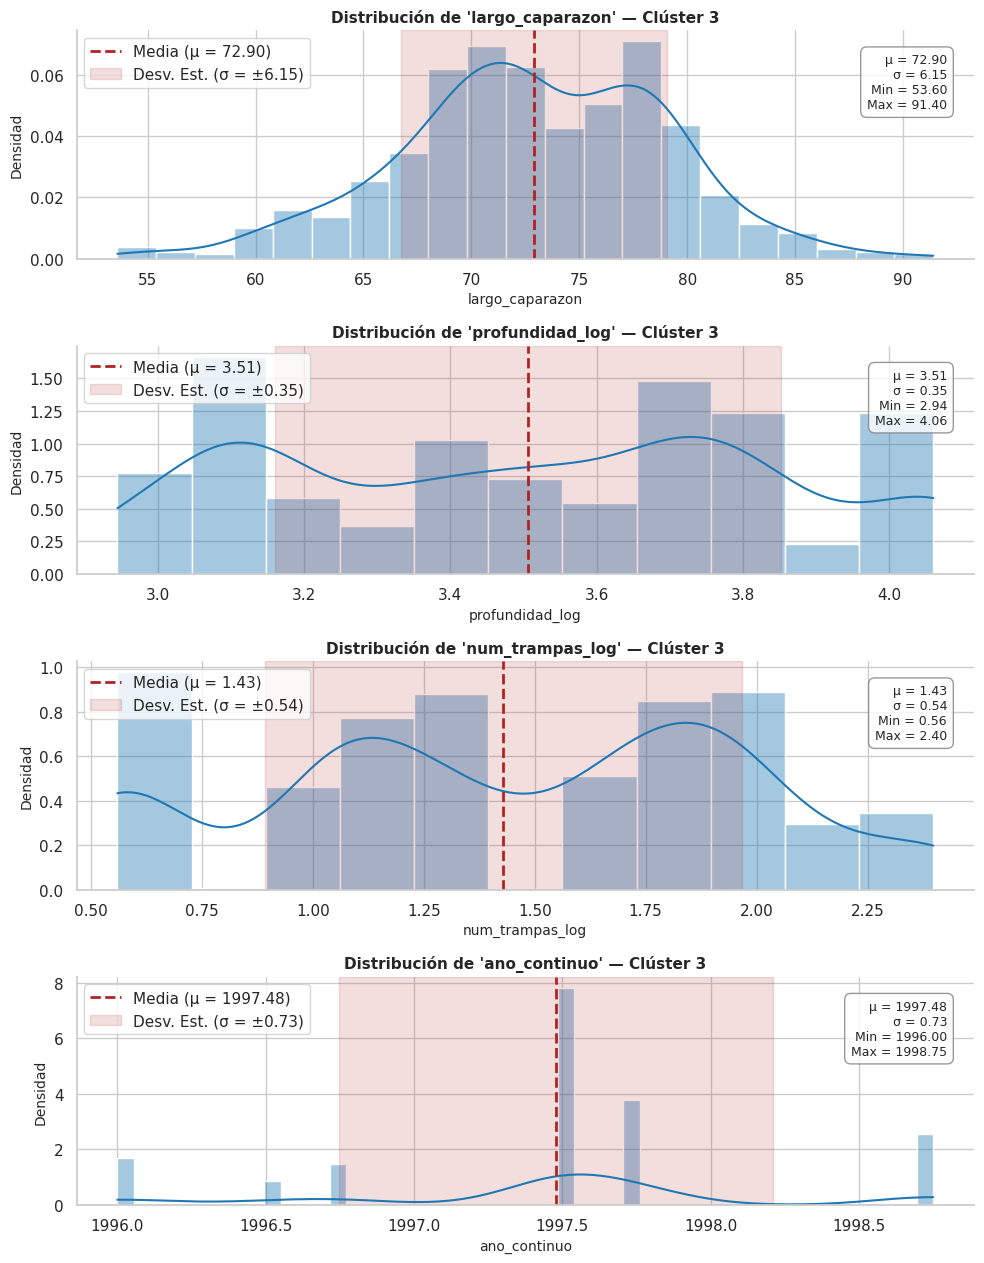

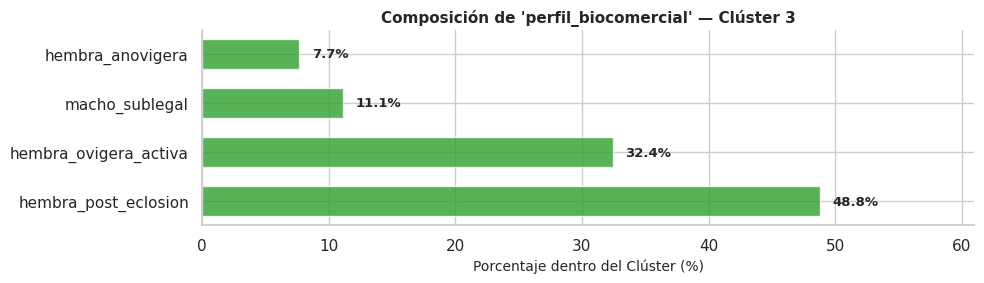

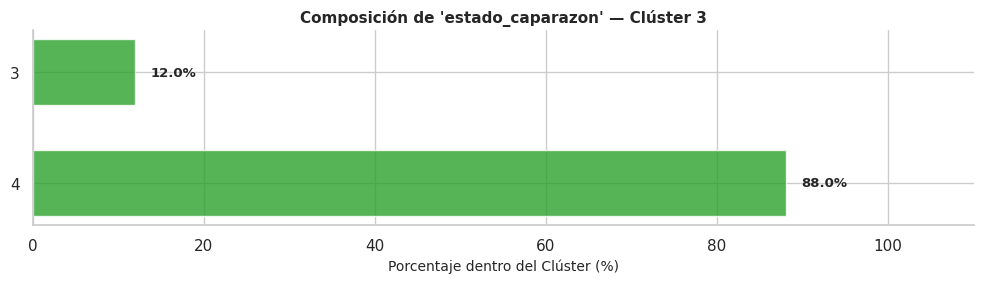

In [89]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")


def inspeccionar_cluster(
    df, cluster_id, num_cols, cat_cols, cluster_col="Cluster"
):
  """Genera un reporte gráfico detallado para un clúster específico,

  calculando media y desviación estándar para variables continuas, y la
  distribución porcentual para variables categóricas.
  """
  # Filtrar subconjunto del clúster seleccionado
  sub_df = df[df[cluster_col] == cluster_id].copy()
  n_muestras = len(sub_df)
  pct_del_total = (n_muestras / len(df)) * 100

  print(f"=========================================================")
  print(
      f"   INSPECCIÓN DETALLADA DE CLÚSTER {cluster_id} (N = {n_muestras},"
      f" {pct_del_total:.1f}% del total)"
  )
  print(f"=========================================================\n")

  # ---------------------------------------------------------
  # 1. VARIABLES CONTINUAS (MEDIA ± DESVIACIÓN ESTÁNDAR)
  # ---------------------------------------------------------
  n_num = len(num_cols)
  fig, axes = plt.subplots(
      n_num, 1, figsize=(10, 3.2 * n_num), sharex=False
  )
  if n_num == 1:
    axes = [axes]

  for i, col in enumerate(num_cols):
    ax = axes[i]
    media = sub_df[col].mean()
    desv = sub_df[col].std()

    # Histogram + KDE
    sns.histplot(
        data=sub_df,
        x=col,
        kde=True,
        color="#1f77b4",
        ax=ax,
        stat="density",
        alpha=0.4,
    )

    # Marcadores visuales para Media y Desviación Estándar
    ax.axvline(
        media,
        color="firebrick",
        linestyle="--",
        linewidth=2,
        label=f"Media (μ = {media:.2f})",
    )
    ax.axvspan(
        media - desv,
        media + desv,
        color="firebrick",
        alpha=0.15,
        label=f"Desv. Est. (σ = ±{desv:.2f})",
    )

    # Anotación en caja flotante
    texto_stats = f"μ = {media:.2f}\nσ = {desv:.2f}\nMin = {sub_df[col].min():.2f}\nMax = {sub_df[col].max():.2f}"
    ax.text(
        0.97,
        0.90,
        texto_stats,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="gray"
        ),
    )

    ax.set_title(
        f"Distribución de '{col}' — Clúster {cluster_id}",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.legend(loc="upper left", frameon=True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

  plt.tight_layout()
  plt.show()

  # ---------------------------------------------------------
  # 2. VARIABLES CATEGÓRICAS (PROPORCIONES DENTRO DEL CLÚSTER)
  # ---------------------------------------------------------
  for col in cat_cols:
    conteo_cat = sub_df[col].value_counts(normalize=True) * 100
    df_cat = conteo_cat.reset_index()
    df_cat.columns = [col, "porcentaje"]

    fig, ax = plt.subplots(figsize=(10, max(3, len(df_cat) * 0.7)))

    bars = ax.barh(
        df_cat[col],
        df_cat["porcentaje"],
        color="#2ca02c",
        alpha=0.8,
        height=0.6,
    )

    # Anotar porcentaje al final de cada barra
    max_val = df_cat["porcentaje"].max()
    for bar, pct in zip(bars, df_cat["porcentaje"]):
      width = bar.get_width()
      ax.text(
          width + (max_val * 0.02),
          bar.get_y() + bar.get_height() / 2,
          f"{pct:.1f}%",
          va="center",
          ha="left",
          fontsize=9.5,
          fontweight="bold",
      )

    ax.set_xlim(0, max_val * 1.25)
    ax.set_title(
        f"Composición de '{col}' — Clúster {cluster_id}",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Porcentaje dentro del Clúster (%)", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# =========================================================
# EJECUCIÓN
# =========================================================

# 1. Preparar DataFrame con datos y clústeres asignados
df_analisis = X_model.copy()
df_analisis["Cluster"] = etiquetas_ward

columnas_continuas = [
    "largo_caparazon",
    "profundidad_log",
    "num_trampas_log",
    "ano_continuo",
]
columnas_categoricas = ["perfil_biocomercial", "estado_caparazon"]

inspeccionar_cluster(
    df=df_analisis,
    cluster_id=CLUSTER_A_INSPECCIONAR,
    num_cols=columnas_continuas,
    cat_cols=columnas_categoricas,
    cluster_col="Cluster",
)